In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import joypy
from matplotlib import cm
plt.style.use('ggplot')
# pd.set_option('max_columns', 200)

In [2]:
df = pd.read_csv('ph_school_enrollment.csv')
df

,item_no,sector,Academic_Year,AY_Start,AY_End,Region,Kindergarten,Grade 1,Grade 2,Grade 3,...,Grade 11 SPORTS,Grade 11 A&D,Grade 12 ABM,Grade 12 HUMSS,Grade 12 STEM,Grade 12 GAS,Grade 12 MARITIME,Grade 12 TVL,Grade 12 SPORTS,Grade 12 A&D
0,1,Public,SY 2010-2011,2010,2011,Region I - Ilocos Region,84553,120004,106298,101393,...,0,0,0,0,0,0,0,0,0,0
1,2,Public,SY 2010-2011,2010,2011,Region II - Cagayan Valley,27079,83959,73674,70180,...,0,0,0,0,0,0,0,0,0,0
2,3,Public,SY 2010-2011,2010,2011,Region III - Central Luzon,141901,258235,221107,210823,...,0,0,0,0,0,0,0,0,0,0
3,4,Public,SY 2010-2011,2010,2011,Region IV-A - CALABARZON,135149,311562,261317,253680,...,0,0,0,0,0,0,0,0,0,0
4,5,Public,SY 2010-2011,2010,2011,Region IV-B - MIMAROPA,47289,100391,82742,76393,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,557,SUC-LUC,SY 2020-2021,2020,2021,Region XII - Soccsksargen,9,24,31,29,...,0,0,93,262,546,60,0,42,0,0
557,558,SUC-LUC,SY 2020-2021,2020,2021,CARAGA - CARAGA,19,34,39,39,...,0,0,0,0,203,0,0,52,0,0
558,559,SUC-LUC,SY 2020-2021,2020,2021,BARMM - Bangsamoro Autonomous Region in Muslim...,100,306,292,341,...,22,0,345,509,1293,690,0,470,28,0
559,560,SUC-LUC,SY 2020-2021,2020,2021,CAR - Cordillera Administrative Region,132,55,60,75,...,0,0,71,289,265,105,0,516,0,0


## Step 1: Data Understanding
1. Dataframe shape
2. head and tail
3. dtypes
4. describe

In [3]:
df.shape

(561, 33)

In [4]:
df.columns

Index(['item_no', 'sector', 'Academic_Year', 'AY_Start', 'AY_End', 'Region',
       'Kindergarten', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5',
       'Grade 6', 'Grade 7', 'Grade 8', 'Grade 9', 'Grade 10', 'Grade 11 ABM',
       'Grade 11 HUMSS', 'Grade 11 STEM', 'Grade 11 GAS', 'Grade 11 MARITIME',
       'Grade 11 TVL', 'Grade 11 SPORTS', 'Grade 11 A&D', 'Grade 12 ABM',
       'Grade 12 HUMSS', 'Grade 12 STEM', 'Grade 12 GAS', 'Grade 12 MARITIME',
       'Grade 12 TVL', 'Grade 12 SPORTS', 'Grade 12 A&D'],
      dtype='object')

In [5]:
df.dtypes

item_no               int64
sector               object
Academic_Year        object
AY_Start              int64
AY_End                int64
Region               object
Kindergarten          int64
Grade 1               int64
Grade 2               int64
Grade 3               int64
Grade 4               int64
Grade 5               int64
Grade 6               int64
Grade 7               int64
Grade 8               int64
Grade 9               int64
Grade 10              int64
Grade 11 ABM          int64
Grade 11 HUMSS        int64
Grade 11 STEM         int64
Grade 11 GAS          int64
Grade 11 MARITIME     int64
Grade 11 TVL          int64
Grade 11 SPORTS       int64
Grade 11 A&D          int64
Grade 12 ABM          int64
Grade 12 HUMSS        int64
Grade 12 STEM         int64
Grade 12 GAS          int64
Grade 12 MARITIME     int64
Grade 12 TVL          int64
Grade 12 SPORTS       int64
Grade 12 A&D          int64
dtype: object

In [6]:
df.describe()

,item_no,AY_Start,AY_End,Kindergarten,Grade 1,Grade 2,Grade 3,Grade 4,Grade 5,Grade 6,...,Grade 11 SPORTS,Grade 11 A&D,Grade 12 ABM,Grade 12 HUMSS,Grade 12 STEM,Grade 12 GAS,Grade 12 MARITIME,Grade 12 TVL,Grade 12 SPORTS,Grade 12 A&D
count,561.000000,561.0000,561.0000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,...,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,281.000000,2015.0000,2016.0000,41339.522282,49033.388592,46791.418895,45502.051693,44453.117647,43866.607843,42577.659537,...,23.777184,57.729055,1381.217469,1650.959002,1542.575758,1875.957219,37.702317,3553.098039,16.992870,43.345811
std,162.091024,3.1651,3.1651,54914.624533,72219.042145,68188.815358,66545.466608,65317.436145,64799.884425,63000.409446,...,61.899705,177.459919,4181.651861,4054.739000,4390.800698,4398.667217,192.241251,8178.685654,47.683817,141.737300
min,1.000000,2010.0000,2011.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,141.000000,2012.0000,2013.0000,132.000000,150.000000,159.000000,162.000000,163.000000,170.000000,164.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,281.000000,2015.0000,2016.0000,11191.000000,6648.000000,6190.000000,6038.000000,5779.000000,5541.000000,5499.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,421.000000,2018.0000,2019.0000,74883.000000,86899.000000,85069.000000,81870.000000,79569.000000,73545.000000,70933.000000,...,2.000000,19.000000,617.000000,766.000000,1055.000000,429.000000,0.000000,1291.000000,0.000000,0.000000
max,561.000000,2020.0000,2021.0000,284579.000000,329623.000000,300402.000000,302636.000000,300415.000000,298349.000000,293281.000000,...,561.000000,1849.000000,35507.000000,28497.000000,33774.000000,29147.000000,2347.000000,40679.000000,403.000000,1453.000000


## Step 2: Data Preparation

1. Dropping irrelevant columns and rows
2. Identifying duplicated columns
3. Renaming columns
4. Feature creation

In [7]:
df.head()

,item_no,sector,Academic_Year,AY_Start,AY_End,Region,Kindergarten,Grade 1,Grade 2,Grade 3,...,Grade 11 SPORTS,Grade 11 A&D,Grade 12 ABM,Grade 12 HUMSS,Grade 12 STEM,Grade 12 GAS,Grade 12 MARITIME,Grade 12 TVL,Grade 12 SPORTS,Grade 12 A&D
0,1,Public,SY 2010-2011,2010,2011,Region I - Ilocos Region,84553,120004,106298,101393,...,0,0,0,0,0,0,0,0,0,0
1,2,Public,SY 2010-2011,2010,2011,Region II - Cagayan Valley,27079,83959,73674,70180,...,0,0,0,0,0,0,0,0,0,0
2,3,Public,SY 2010-2011,2010,2011,Region III - Central Luzon,141901,258235,221107,210823,...,0,0,0,0,0,0,0,0,0,0
3,4,Public,SY 2010-2011,2010,2011,Region IV-A - CALABARZON,135149,311562,261317,253680,...,0,0,0,0,0,0,0,0,0,0
4,5,Public,SY 2010-2011,2010,2011,Region IV-B - MIMAROPA,47289,100391,82742,76393,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.drop(columns=['item_no'], errors='ignore').copy()

,sector,Academic_Year,AY_Start,AY_End,Region,Kindergarten,Grade 1,Grade 2,Grade 3,Grade 4,...,Grade 11 SPORTS,Grade 11 A&D,Grade 12 ABM,Grade 12 HUMSS,Grade 12 STEM,Grade 12 GAS,Grade 12 MARITIME,Grade 12 TVL,Grade 12 SPORTS,Grade 12 A&D
0,Public,SY 2010-2011,2010,2011,Region I - Ilocos Region,84553,120004,106298,101393,100785,...,0,0,0,0,0,0,0,0,0,0
1,Public,SY 2010-2011,2010,2011,Region II - Cagayan Valley,27079,83959,73674,70180,68135,...,0,0,0,0,0,0,0,0,0,0
2,Public,SY 2010-2011,2010,2011,Region III - Central Luzon,141901,258235,221107,210823,208874,...,0,0,0,0,0,0,0,0,0,0
3,Public,SY 2010-2011,2010,2011,Region IV-A - CALABARZON,135149,311562,261317,253680,244886,...,0,0,0,0,0,0,0,0,0,0
4,Public,SY 2010-2011,2010,2011,Region IV-B - MIMAROPA,47289,100391,82742,76393,71897,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,SUC-LUC,SY 2020-2021,2020,2021,Region XII - Soccsksargen,9,24,31,29,20,...,0,0,93,262,546,60,0,42,0,0
557,SUC-LUC,SY 2020-2021,2020,2021,CARAGA - CARAGA,19,34,39,39,27,...,0,0,0,0,203,0,0,52,0,0
558,SUC-LUC,SY 2020-2021,2020,2021,BARMM - Bangsamoro Autonomous Region in Muslim...,100,306,292,341,337,...,22,0,345,509,1293,690,0,470,28,0
559,SUC-LUC,SY 2020-2021,2020,2021,CAR - Cordillera Administrative Region,132,55,60,75,95,...,0,0,71,289,265,105,0,516,0,0


In [9]:
print(df.columns)

Index(['item_no', 'sector', 'Academic_Year', 'AY_Start', 'AY_End', 'Region',
       'Kindergarten', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5',
       'Grade 6', 'Grade 7', 'Grade 8', 'Grade 9', 'Grade 10', 'Grade 11 ABM',
       'Grade 11 HUMSS', 'Grade 11 STEM', 'Grade 11 GAS', 'Grade 11 MARITIME',
       'Grade 11 TVL', 'Grade 11 SPORTS', 'Grade 11 A&D', 'Grade 12 ABM',
       'Grade 12 HUMSS', 'Grade 12 STEM', 'Grade 12 GAS', 'Grade 12 MARITIME',
       'Grade 12 TVL', 'Grade 12 SPORTS', 'Grade 12 A&D'],
      dtype='object')


In [10]:
df.shape

(561, 33)

In [11]:
df.isna().sum()

item_no              0
sector               0
Academic_Year        0
AY_Start             0
AY_End               0
Region               0
Kindergarten         0
Grade 1              0
Grade 2              0
Grade 3              0
Grade 4              0
Grade 5              0
Grade 6              0
Grade 7              0
Grade 8              0
Grade 9              0
Grade 10             0
Grade 11 ABM         0
Grade 11 HUMSS       0
Grade 11 STEM        0
Grade 11 GAS         0
Grade 11 MARITIME    0
Grade 11 TVL         0
Grade 11 SPORTS      0
Grade 11 A&D         0
Grade 12 ABM         0
Grade 12 HUMSS       0
Grade 12 STEM        0
Grade 12 GAS         0
Grade 12 MARITIME    0
Grade 12 TVL         0
Grade 12 SPORTS      0
Grade 12 A&D         0
dtype: int64

In [12]:
df.loc[df.duplicated()]

,item_no,sector,Academic_Year,AY_Start,AY_End,Region,Kindergarten,Grade 1,Grade 2,Grade 3,...,Grade 11 SPORTS,Grade 11 A&D,Grade 12 ABM,Grade 12 HUMSS,Grade 12 STEM,Grade 12 GAS,Grade 12 MARITIME,Grade 12 TVL,Grade 12 SPORTS,Grade 12 A&D


## Step 3: Feature Understanding

(Univariate analysis)

1. Plotting Feature Distributions
    
    1.1. Histogram
    
    1.2. KDE
    
    1.3. Boxplot

In [13]:
sns.set_style("whitegrid")

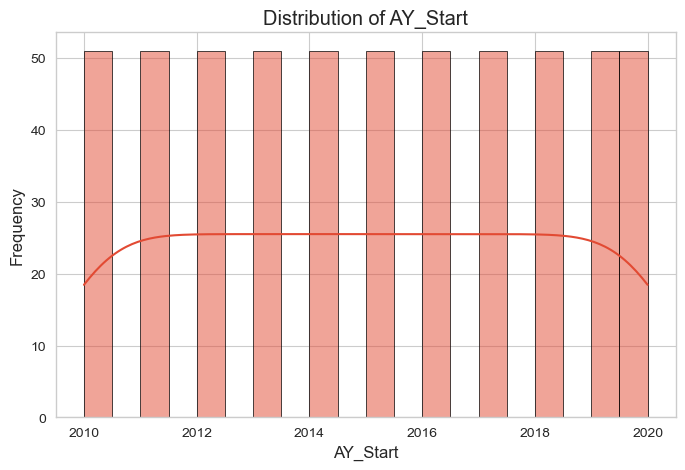

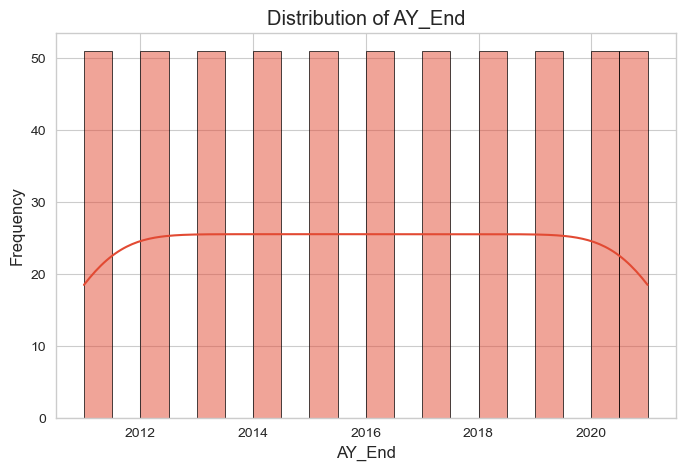

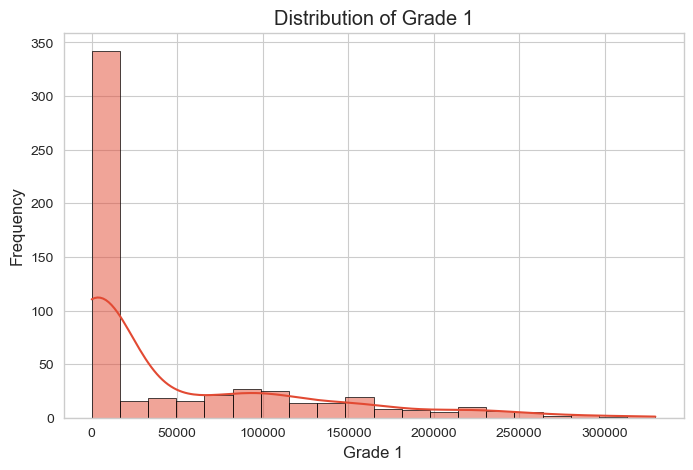

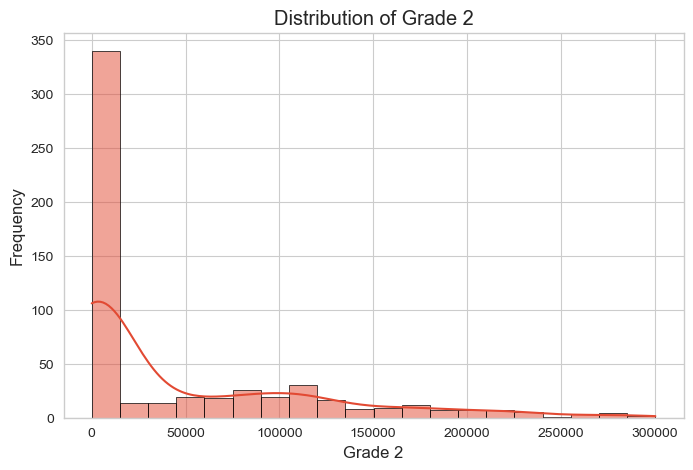

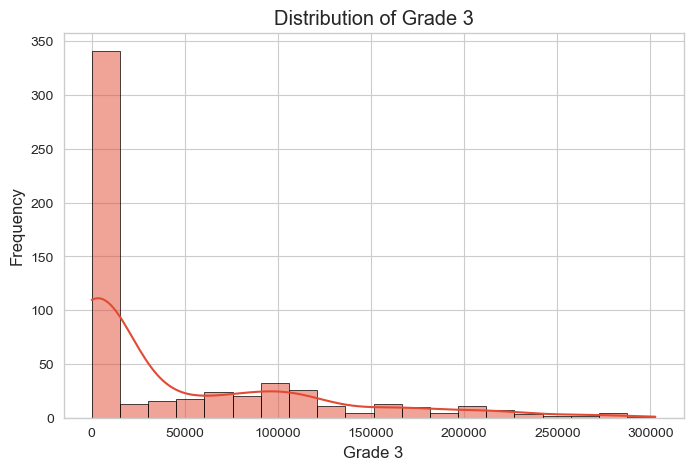

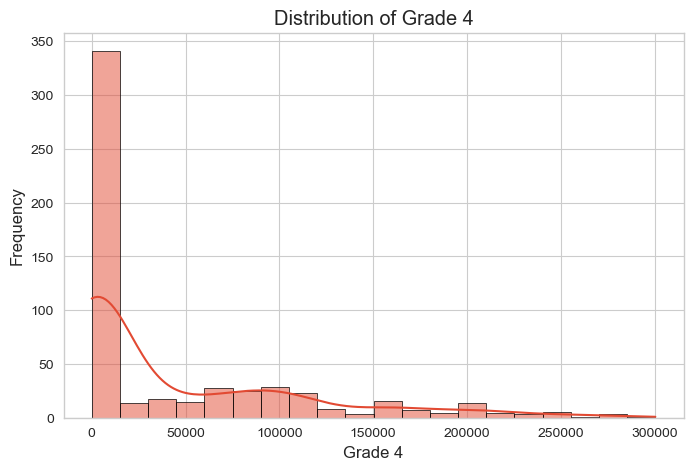

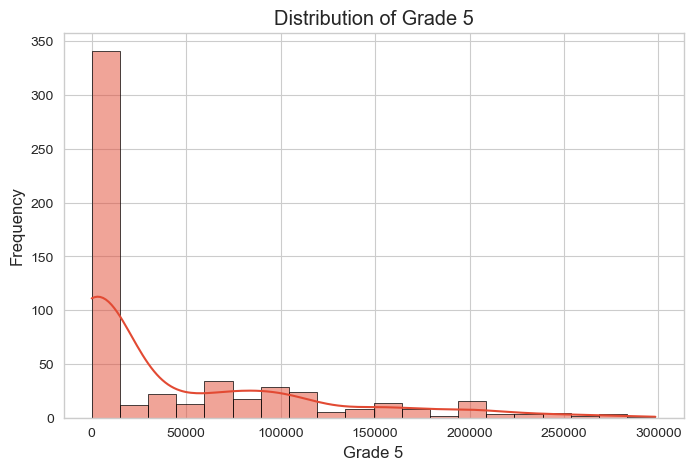

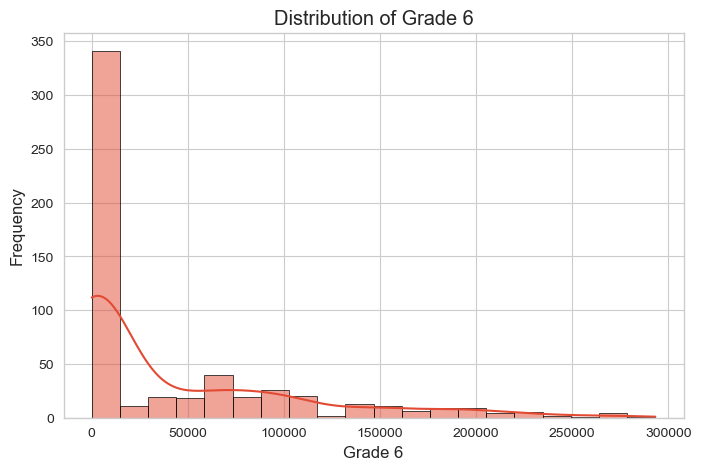

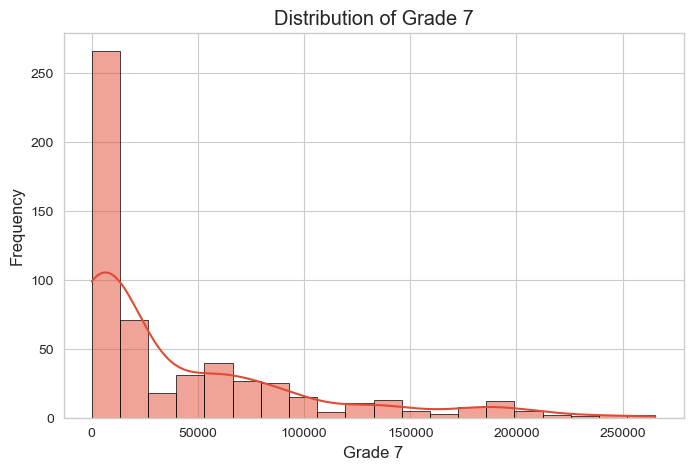

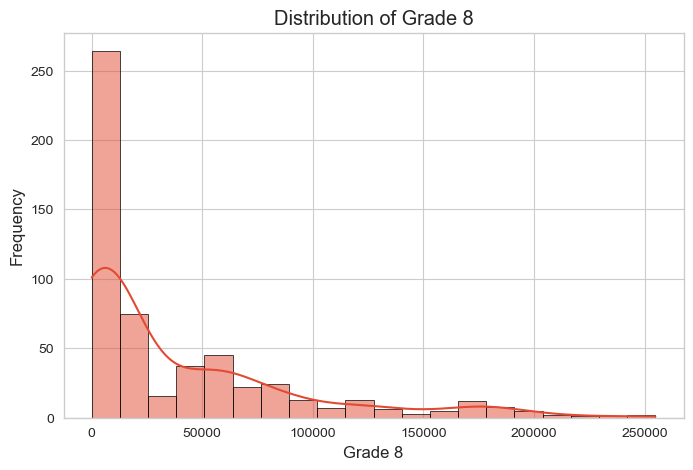

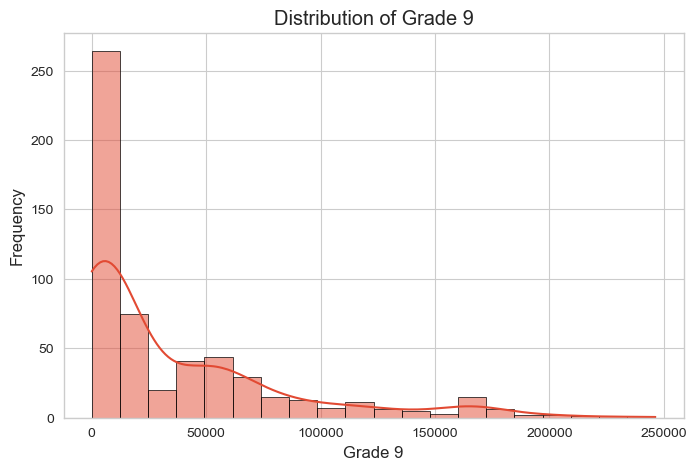

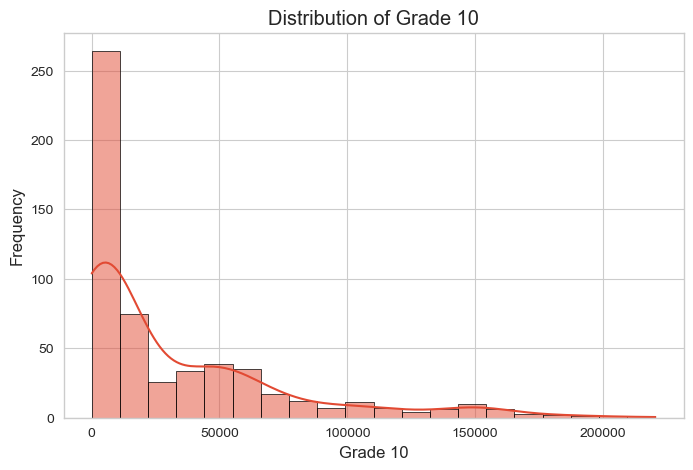

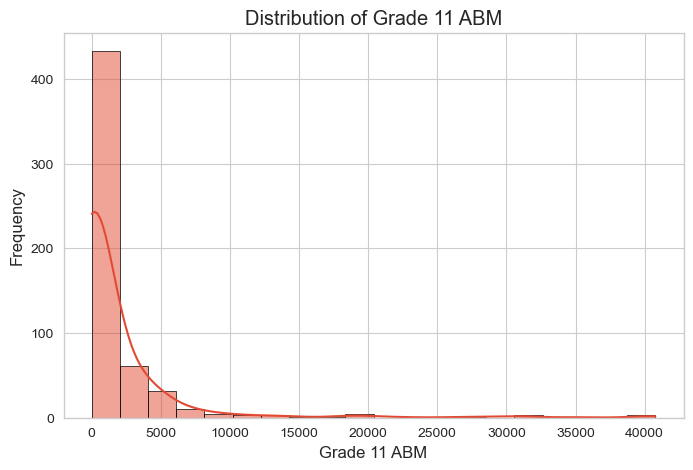

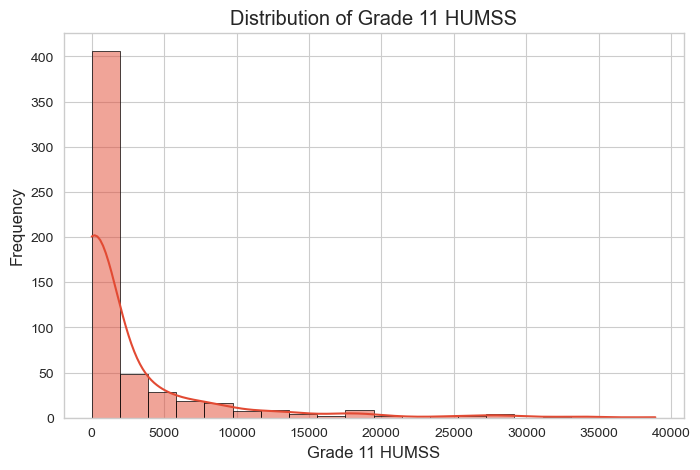

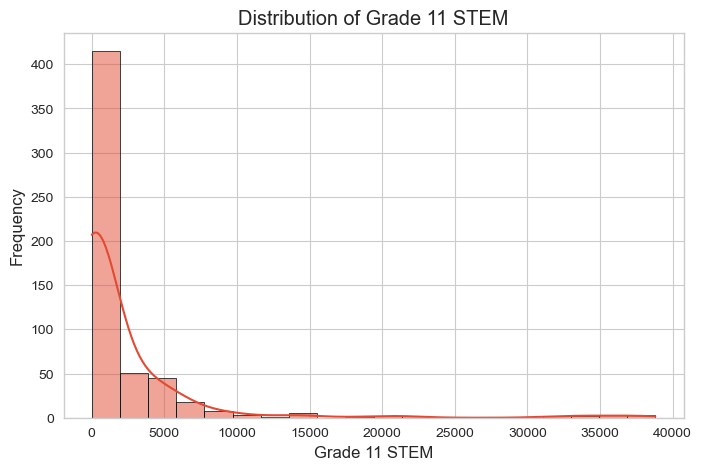

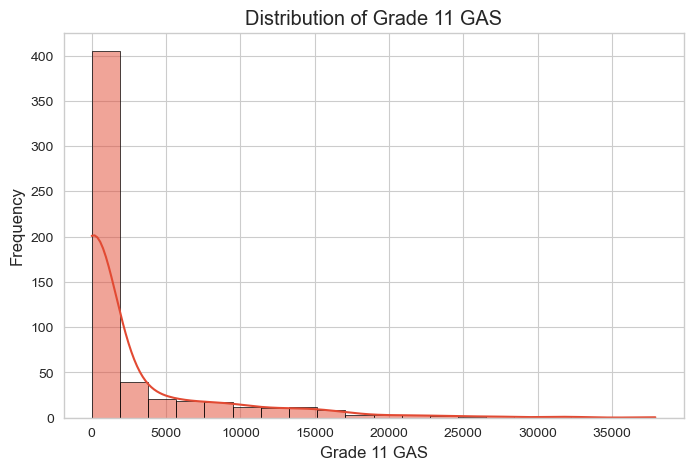

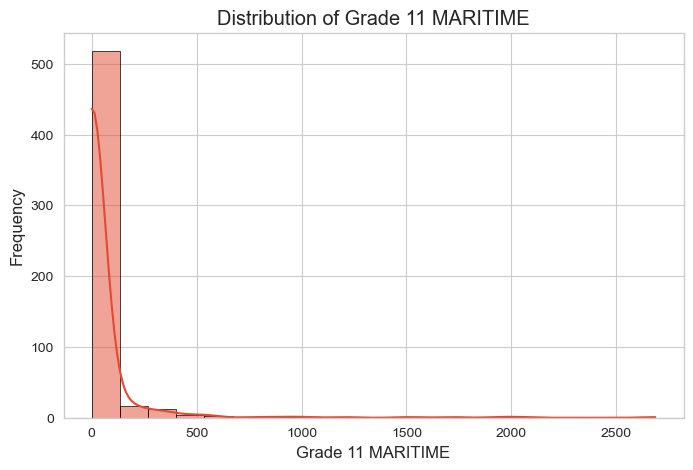

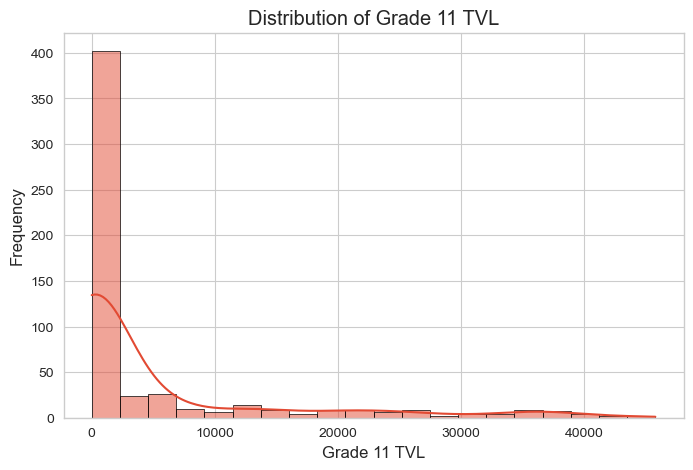

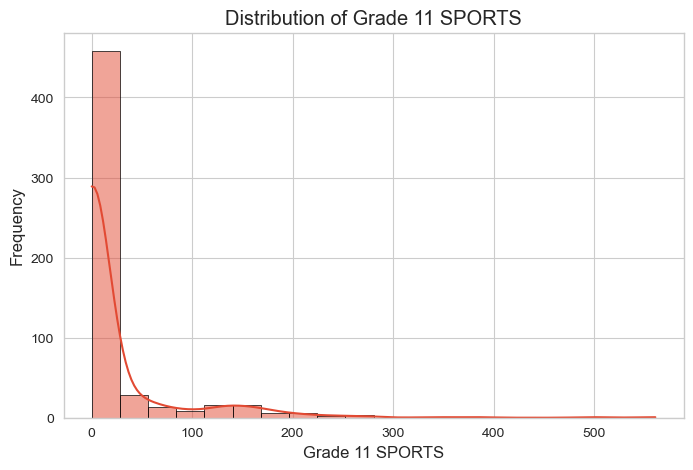

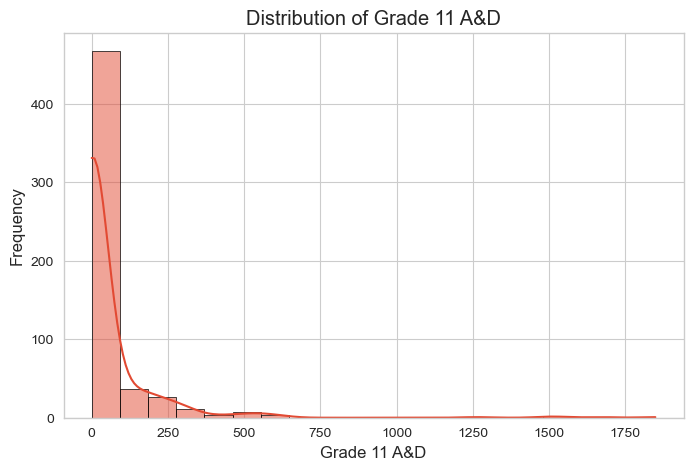

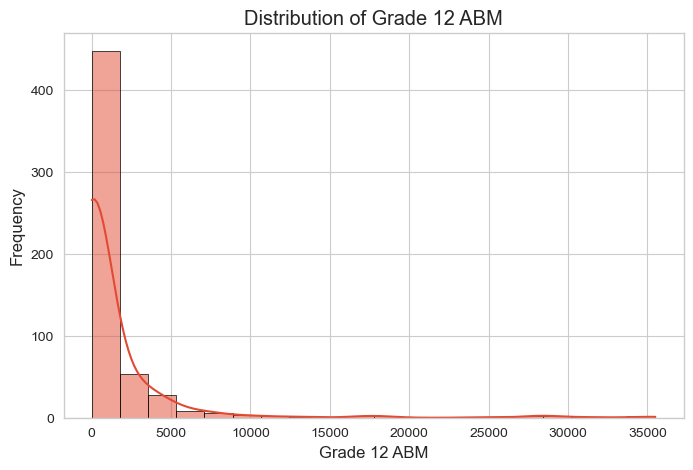

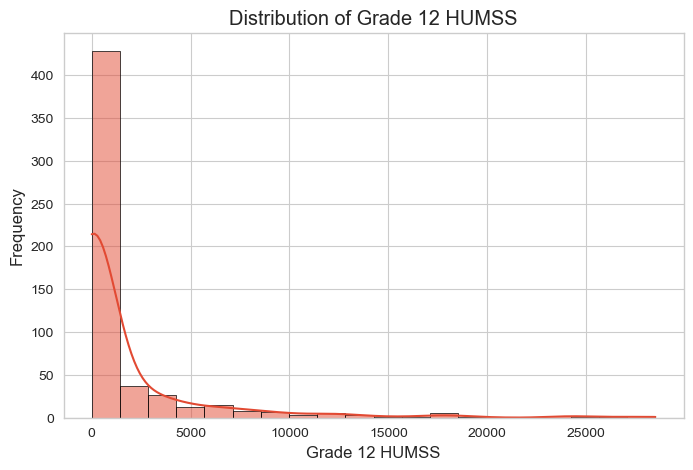

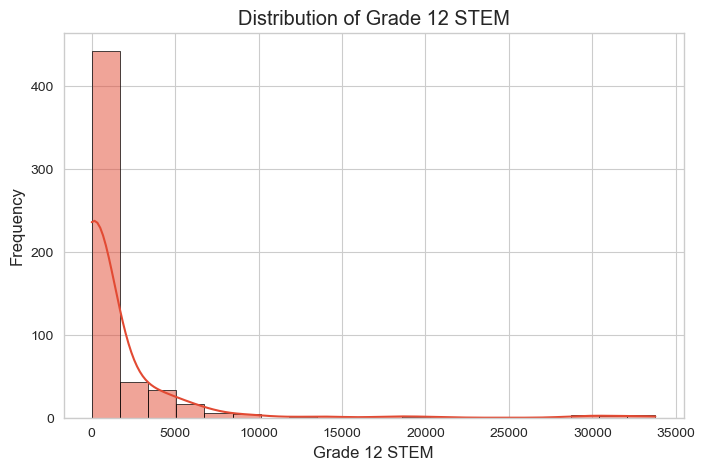

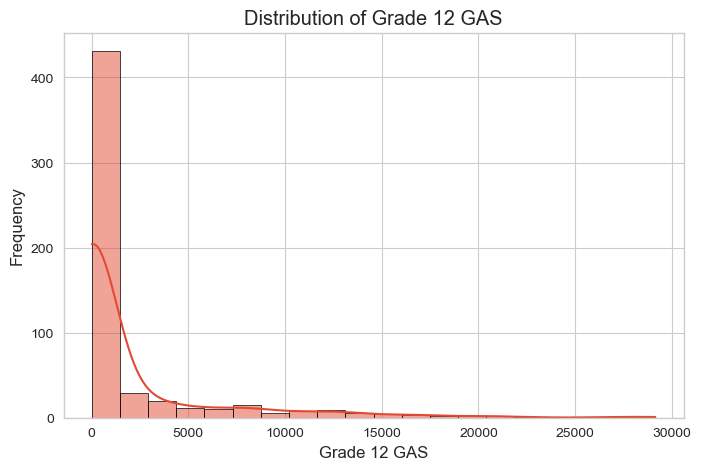

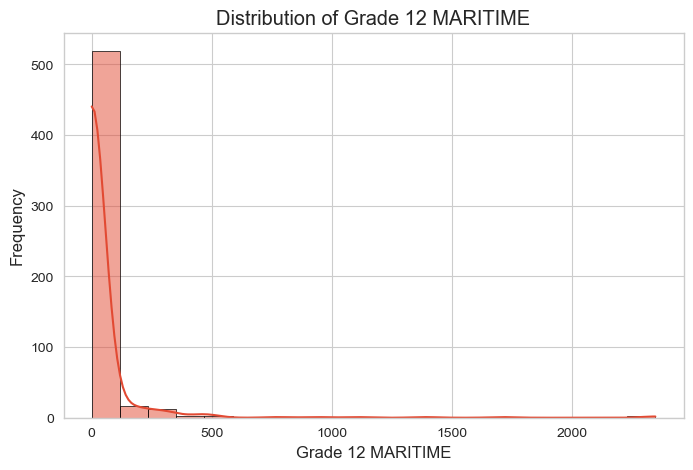

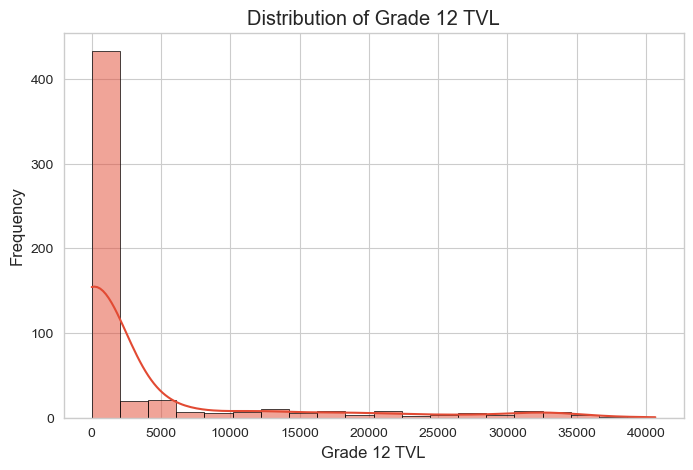

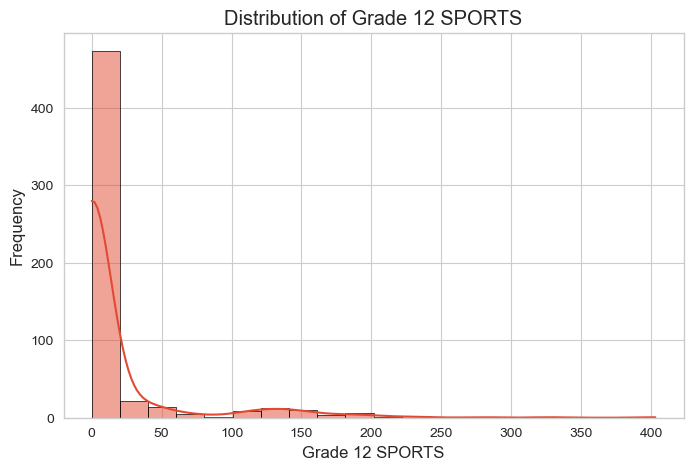

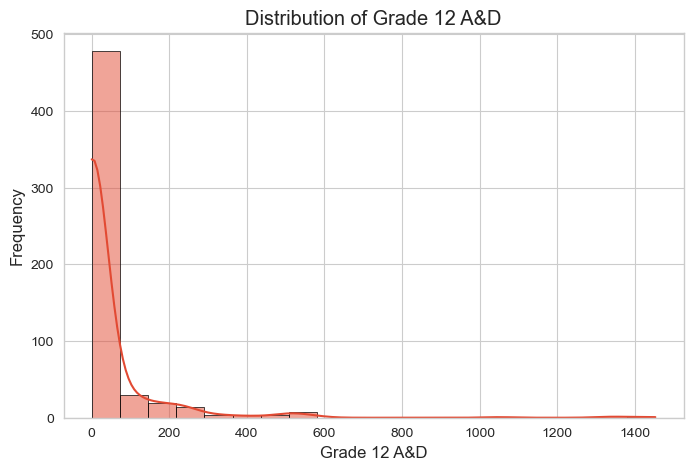

In [14]:
def plot_histogram(column):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], bins=20, kde=True, edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()
    
numeric_cols = [col for col in df.columns if "Grade" in col or "AY_" in col]
for col in numeric_cols:
    plot_histogram(col)

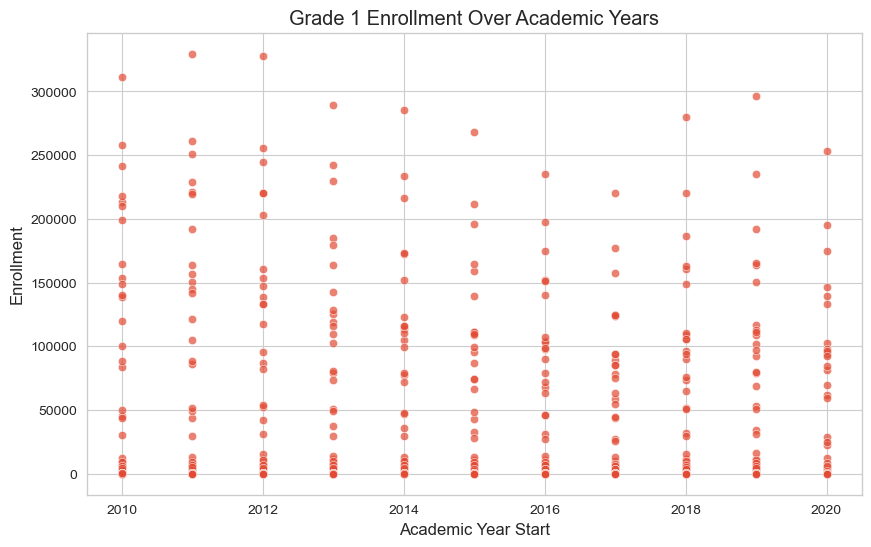

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["AY_Start"], y=df["Grade 1"], alpha=0.7)
plt.title("Grade 1 Enrollment Over Academic Years")
plt.xlabel("Academic Year Start")
plt.ylabel("Enrollment")
plt.show()

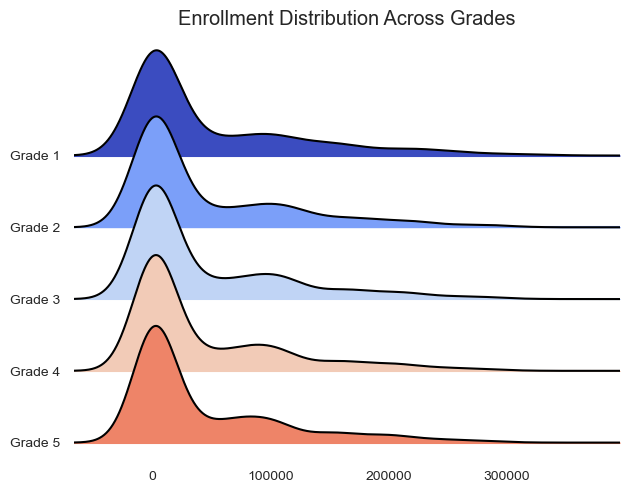

In [16]:
grade_columns = ["Grade 1", "Grade 2", "Grade 3", "Grade 4", "Grade 5"]
joypy.joyplot(df[grade_columns], colormap=cm.coolwarm)
plt.title("Enrollment Distribution Across Grades")
plt.show()

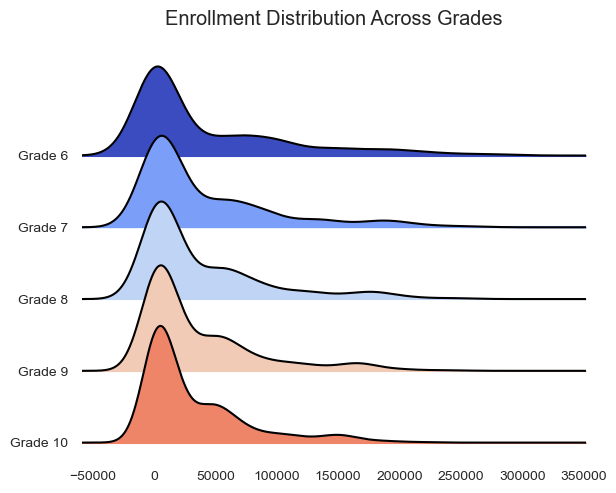

In [17]:
grade_columns = ["Grade 6", "Grade 7", "Grade 8", "Grade 9", "Grade 10"]
joypy.joyplot(df[grade_columns], colormap=cm.coolwarm)
plt.title("Enrollment Distribution Across Grades")
plt.show()

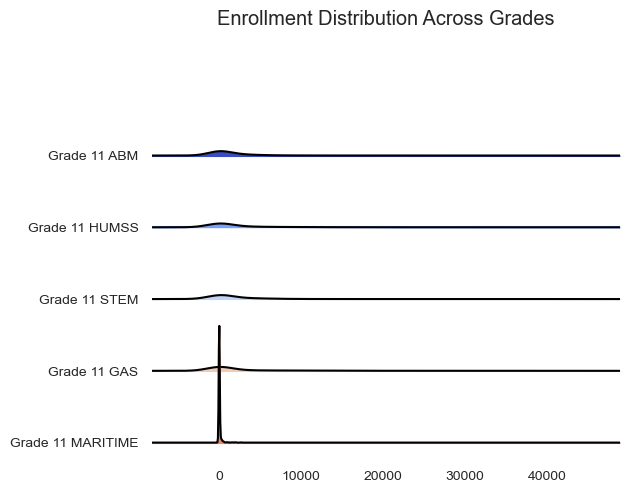

In [18]:
grade_columns = ["Grade 11 ABM", "Grade 11 HUMSS", "Grade 11 STEM", "Grade 11 GAS", "Grade 11 MARITIME"]
joypy.joyplot(df[grade_columns], colormap=cm.coolwarm)
plt.title("Enrollment Distribution Across Grades")
plt.show()

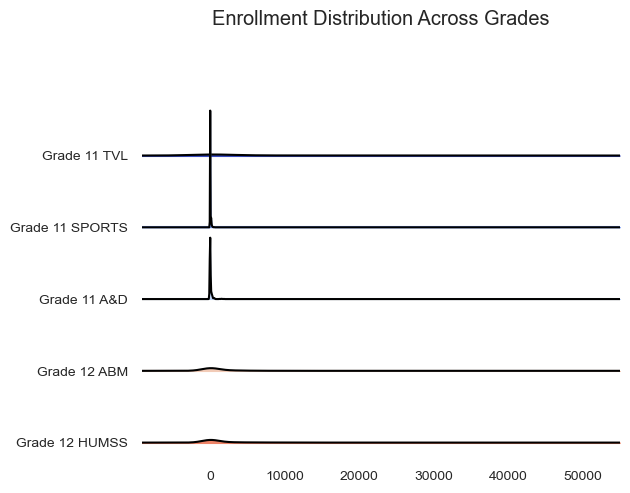

In [19]:
grade_columns = ["Grade 11 TVL", "Grade 11 SPORTS", "Grade 11 A&D", "Grade 12 ABM", "Grade 12 HUMSS"]
joypy.joyplot(df[grade_columns], colormap=cm.coolwarm)
plt.title("Enrollment Distribution Across Grades")
plt.show()

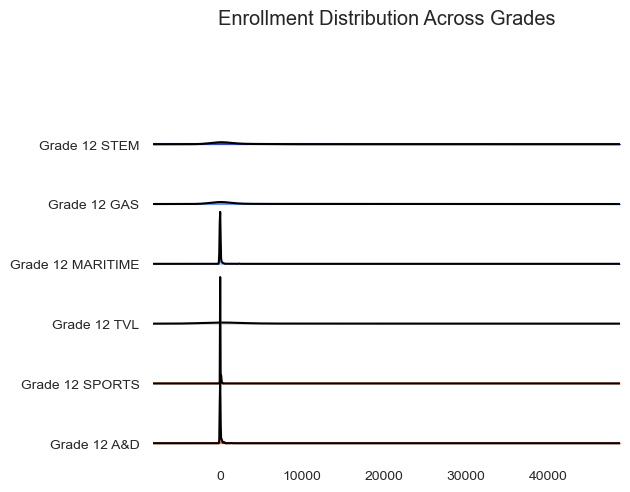

In [20]:
grade_columns = ["Grade 12 STEM", "Grade 12 GAS", "Grade 12 MARITIME", "Grade 12 TVL", "Grade 12 SPORTS", \
                 "Grade 12 A&D"]
joypy.joyplot(df[grade_columns], colormap=cm.coolwarm)
plt.title("Enrollment Distribution Across Grades")
plt.show()

## Step 4: Feature Relationships

1. Scatterplot
2. Heatmap Correlation
3. Pairplot
4. Groupby comparisons

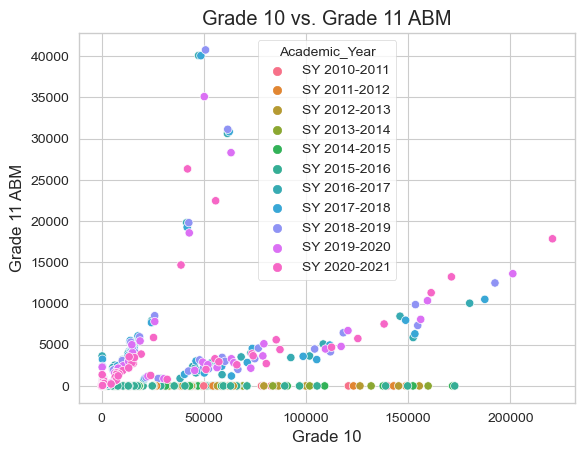

In [21]:
ax = sns.scatterplot(x = 'Grade 10', y = 'Grade 11 ABM', hue = 'Academic_Year',
       data = df)
ax.set_title("Grade 10 vs. Grade 11 ABM")
plt.show()

c:\Users\franj\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


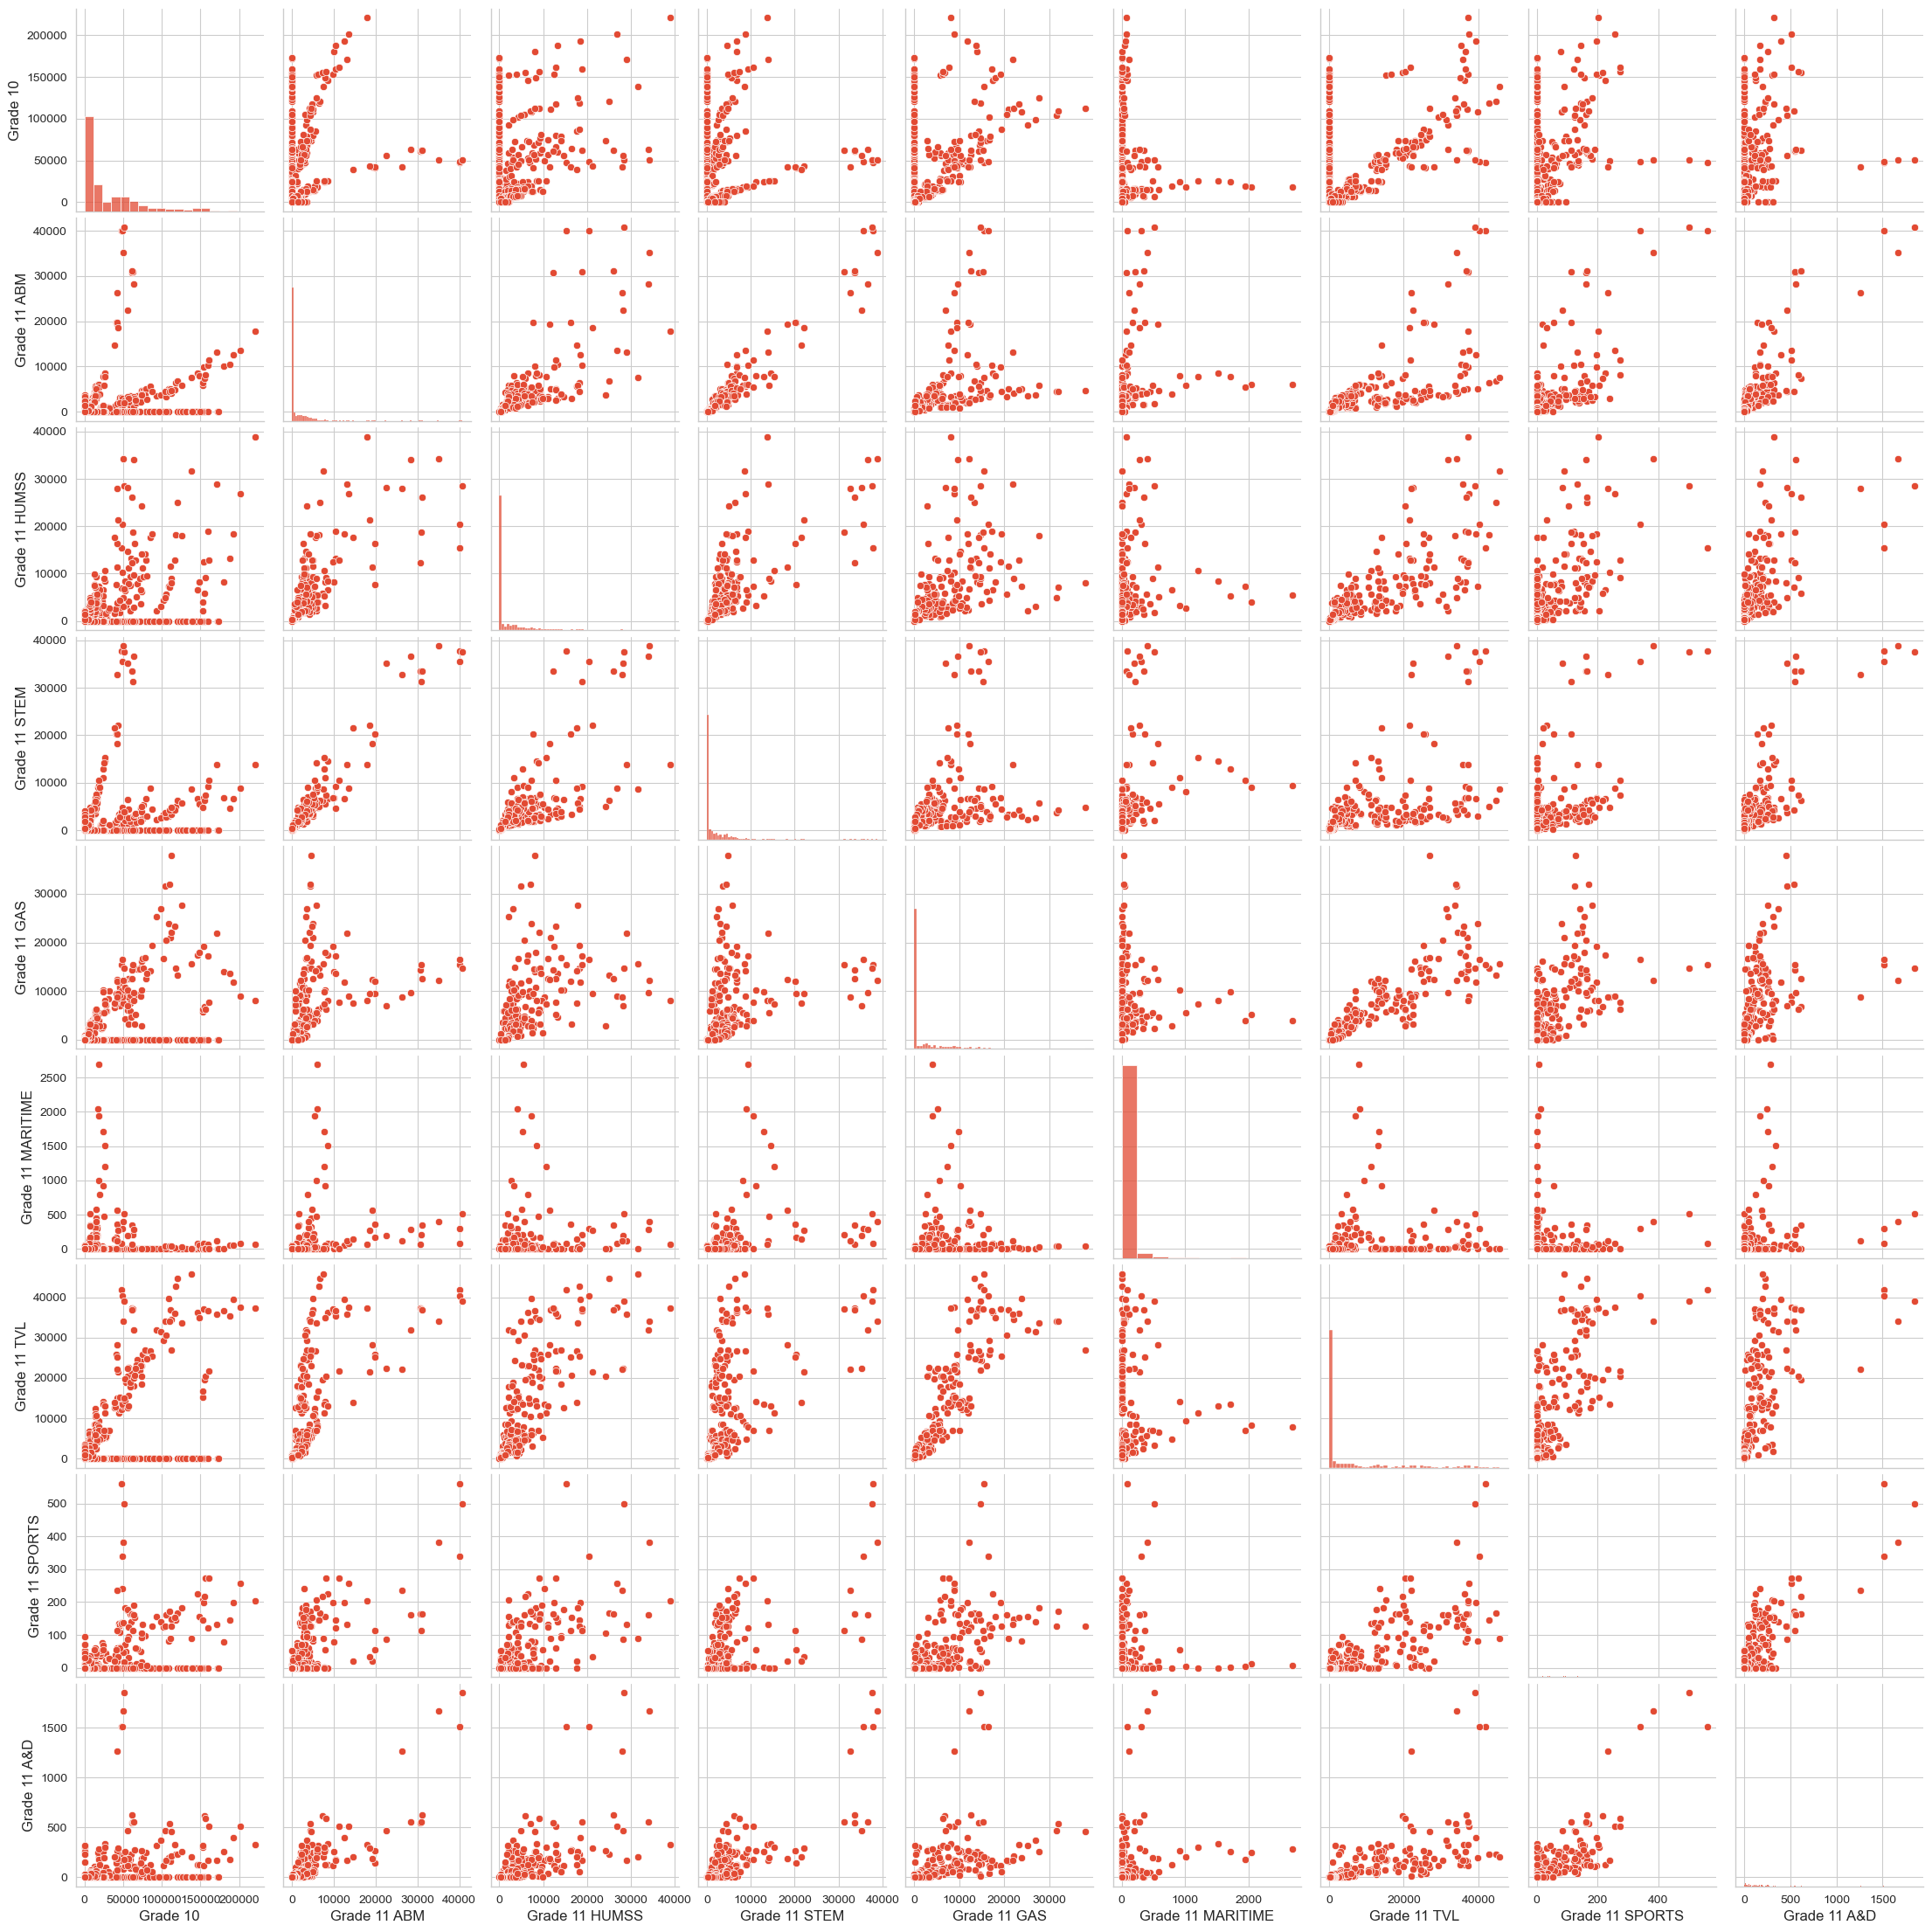

In [22]:
sns.pairplot(df, vars = ['Grade 10', 'Grade 11 ABM',
       'Grade 11 HUMSS', 'Grade 11 STEM', 'Grade 11 GAS', 'Grade 11 MARITIME',
       'Grade 11 TVL', 'Grade 11 SPORTS', 'Grade 11 A&D'])
plt.show()

In [23]:
df_corr = df[['Grade 10', 'Grade 11 ABM',
       'Grade 11 HUMSS', 'Grade 11 STEM', 'Grade 11 GAS', 'Grade 11 MARITIME',
       'Grade 11 TVL', 'Grade 11 SPORTS', 'Grade 11 A&D']].dropna().corr()
df_corr

,Grade 10,Grade 11 ABM,Grade 11 HUMSS,Grade 11 STEM,Grade 11 GAS,Grade 11 MARITIME,Grade 11 TVL,Grade 11 SPORTS,Grade 11 A&D
Grade 10,1.000000,0.287534,0.437321,0.205413,0.494870,-0.024563,0.562046,0.451793,0.298398
Grade 11 ABM,0.287534,1.000000,0.793558,0.969054,0.550304,0.308648,0.720704,0.740142,0.874231
Grade 11 HUMSS,0.437321,0.793558,1.000000,0.790343,0.655455,0.222305,0.833241,0.713310,0.697595
Grade 11 STEM,0.205413,0.969054,0.790343,1.000000,0.503094,0.392830,0.650775,0.649517,0.827903
Grade 11 GAS,0.494870,0.550304,0.655455,0.503094,1.000000,0.164465,0.898657,0.670179,0.560657
Grade 11 MARITIME,-0.024563,0.308648,0.222305,0.392830,0.164465,1.000000,0.163887,0.066123,0.265576
Grade 11 TVL,0.562046,0.720704,0.833241,0.650775,0.898657,0.163887,1.000000,0.778197,0.675105
Grade 11 SPORTS,0.451793,0.740142,0.713310,0.649517,0.670179,0.066123,0.778197,1.000000,0.842665
Grade 11 A&D,0.298398,0.874231,0.697595,0.827903,0.560657,0.265576,0.675105,0.842665,1.000000


<Axes: >

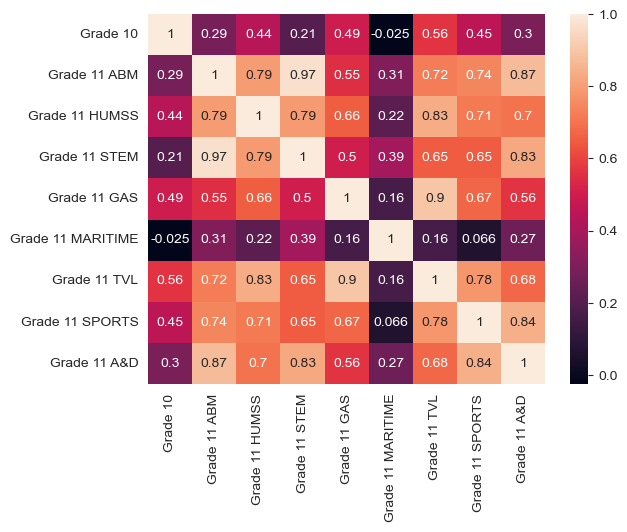

In [25]:
sns.heatmap(df_corr, annot = True) #better than scatterplot